In [478]:
import copy
import json
import os
import pickle
import random
import socket
import subprocess
from datetime import datetime
from pathlib import Path

import imageio
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from IPython.display import display

import robomimic
import robomimic.envs
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.torch_utils as TorchUtils

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

print("hostname:", socket.gethostname())
print("pid:", os.getpid())
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device count:", torch.cuda.device_count())
    print("current device:", torch.cuda.current_device())
    subprocess.run(["nvidia-smi", "-L"], check=False)

hostname: mk-c
pid: 2671072
cuda available: True
cuda device count: 1
current device: 0
GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-09d77f1f-8992-15cc-7b76-e48a47442fcd)


In [483]:
# Load automaton world model, diffusion policy, and environment

DP_CKPT_PATH = "/home/moritz/data/diffusion_runs/toy_squares_dp_n500/20260422190540/models/model_epoch_320_best_validation_0.005075077305082232.pth"
AUTOMATON_RUN_DIR = Path("/home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_17-52-27")

assert Path(DP_CKPT_PATH).exists(), f"Policy checkpoint not found: {DP_CKPT_PATH}"
assert (AUTOMATON_RUN_DIR / "best_model.pt").exists(), f"Automaton checkpoint not found: {AUTOMATON_RUN_DIR / 'best_model.pt'}"

import importlib

try:
    import toy_squares.toy_squares_utils as ts_utils
except ModuleNotFoundError:
    import toy_squares_utils as ts_utils

ts_utils = importlib.reload(ts_utils)
load_automaton_model_for_eval = ts_utils.load_automaton_model_for_eval

device = TorchUtils.get_torch_device(try_to_use_cuda=True)
policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=DP_CKPT_PATH, device=device, verbose=False)
env, _ = FileUtils.env_from_checkpoint(ckpt_dict=ckpt_dict, render=False, render_offscreen=True, verbose=False)
env.reset()
automaton_model, eval_stats, _, eval_meta = load_automaton_model_for_eval(
    model_or_run_path=str(AUTOMATON_RUN_DIR),
    predictor_kind="learned",
    device=device,
    load_val_trajectories=False,
)

print("Loaded policy and environment successfully.")
print("Loaded automaton world model from:", eval_meta["ckpt_path"])
print("Environment type:", type(env))


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['agent_pos']
using obs modality: rgb with keys: ['image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.710221e+07
Created environment with name TouchCube
Action size is 2
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
Loaded policy and environment successfully.
Loaded automaton world model from: /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_17-52-27/best_model.pt
Environment type: <class 'robomimic.envs.wrappers.FrameStackWrapper'>


In [ ]:
# Rollout helpers (with GIF export)

try:
    from toy_squares.toy_squares_utils import early_decision_cube_setup, late_decision_cube_setup
except ModuleNotFoundError:
    from toy_squares_utils import early_decision_cube_setup, late_decision_cube_setup

OUTPUT_ROOT = Path("/home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance")
STATE_BLOCK_NAMES = ["blue", "red", "green", "yellow"]
LABEL_NAMES = ["at_green", "at_blue", "at_red", "at_yellow"]
LABEL_TO_STATE_BLOCK_IDX = [2, 0, 1, 3]
STATE_BLOCK_TO_LABEL_IDX = [1, 2, 0, 3]


def _checkpoint_tag(path_str):
    return Path(path_str).name


def _to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def _obs_low_level_snapshot(obs):
    snapshot = {}
    for key in ["states", "agent_pos"]:
        if key in obs:
            snapshot[key] = _to_numpy(obs[key]).copy()
    return snapshot


def _render_frame(env, height=512, width=512, camera_name="agentview"):
    try:
        return env.render(mode="rgb_array", height=height, width=width, camera_name=camera_name)
    except TypeError:
        return env.render(mode="rgb_array", height=height, width=width)


def _stack_or_object(values):
    values = list(values)
    if not values:
        return np.array([])
    try:
        return np.stack(values)
    except Exception:
        return np.array(values, dtype=object)


def print_label_mapping():
    print("State block order:", STATE_BLOCK_NAMES)
    print("Label order:", LABEL_NAMES)
    print("Label idx -> state block:", {i: STATE_BLOCK_NAMES[j] for i, j in enumerate(LABEL_TO_STATE_BLOCK_IDX)})
    print("State block -> label idx:", {name: STATE_BLOCK_TO_LABEL_IDX[i] for i, name in enumerate(STATE_BLOCK_NAMES)})


def _scale_tag(scale):
    return str(float(scale)).replace(".", "p").replace("-", "m")


def _list_tag(values):
    return "-".join(_scale_tag(value) for value in values)


def reseed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _latest_obs_tensor(obs_dict, key):
    value = obs_dict[key]
    if not torch.is_tensor(value):
        value = torch.as_tensor(value, device=device, dtype=torch.float32)
    value = value.float()
    expected_dim = {"agent_pos": 2, "states": 8}[key]
    if value.shape[-1] != expected_dim:
        raise ValueError(f"Expected obs['{key}'] last dim {expected_dim}, got shape {tuple(value.shape)}.")
    if value.ndim == 3:
        # Diffusion policy observes a frame stack: (batch, time, dim). Use the latest frame.
        return value[:, -1, :]
    if value.ndim == 2:
        # Accept either already-batched (1, dim) or unbatched stacked (time, dim).
        return value if value.shape[0] == 1 else value[-1:, :]
    if value.ndim == 1:
        return value.unsqueeze(0)
    raise ValueError(f"Expected obs['{key}'] with shape (B,T,D), (T,D), (B,D), or (D,), got {tuple(value.shape)}.")


def _automaton_state_from_obs(obs_dict):
    state = torch.cat([_latest_obs_tensor(obs_dict, "agent_pos"), _latest_obs_tensor(obs_dict, "states")], dim=-1)
    if state.shape[-1] != 10:
        raise ValueError(f"Expected 10D automaton state, got shape {tuple(state.shape)}.")
    return state


def _automaton_label_from_state(state, cube_radius=0.2, collapse_to_nearest=True):
    agent = state[:, 0:2]
    cubes = state[:, 2:10].reshape(state.shape[0], 4, 2)
    distances = torch.linalg.norm(agent[:, None, :] - cubes, dim=-1)
    contact = (cube_radius - distances >= 0.0).float()
    if collapse_to_nearest:
        has_contact = contact.bool().any(dim=-1)
        active_distances = torch.where(contact.bool(), distances, torch.full_like(distances, float("inf")))
        nearest_active = active_distances.argmin(dim=-1)
        contact_onehot = torch.zeros_like(contact)
        contact_onehot.scatter_(1, nearest_active[:, None], has_contact.to(contact.dtype)[:, None])
        contact = contact_onehot
    return torch.stack([contact[:, 2], contact[:, 0], contact[:, 1], contact[:, 3]], dim=-1)


def _latest_low_level_vector(value):
    array = np.asarray(_to_numpy(value), dtype=np.float32)
    if array.ndim >= 2:
        array = array[-1]
    return array.reshape(-1)


def _state_vector_from_low_level_obs(obs):
    # Match label_world_model.py: [latest agent_pos, latest blue/red/green/yellow positions].
    state = np.concatenate([
        _latest_low_level_vector(obs["agent_pos"]),
        _latest_low_level_vector(obs["states"]),
    ]).astype(np.float32)
    if state.shape != (10,):
        raise ValueError(f"Expected 10D automaton state, got shape {state.shape}.")
    return state


def label_from_low_level_obs(obs, cube_radius=0.2):
    state = torch.as_tensor(_state_vector_from_low_level_obs(obs), device=device, dtype=torch.float32).unsqueeze(0)
    label = _automaton_label_from_state(state, cube_radius=cube_radius)[0].detach().cpu().numpy().astype(int)
    active = [LABEL_NAMES[i] for i, value in enumerate(label) if value]
    agent = state[0, 0:2]
    cubes = state[0, 2:10].reshape(4, 2)
    distances = torch.linalg.norm(agent[None, :] - cubes, dim=-1).detach().cpu().numpy()
    nearest_state_block_idx = int(np.argmin(distances))
    return {
        "onehot": label.tolist(),
        "active_labels": active,
        "nearest_state_block_idx": nearest_state_block_idx,
        "nearest_state_block": STATE_BLOCK_NAMES[nearest_state_block_idx],
        "nearest_label_idx": int(STATE_BLOCK_TO_LABEL_IDX[nearest_state_block_idx]),
        "distances_by_state_block": {name: float(distances[i]) for i, name in enumerate(STATE_BLOCK_NAMES)},
    }


def make_automaton_guidance_fn(predictor, stats, policy, device, target_label_idx=1):
    state_mean = torch.tensor(stats["states_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    state_std = torch.tensor(stats["states_std"], device=device, dtype=torch.float32).unsqueeze(0)
    action_mean = torch.tensor(stats["actions_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    action_std = torch.tensor(stats["actions_std"], device=device, dtype=torch.float32).unsqueeze(0)
    start = int(policy.policy.algo_config.horizon.observation_horizon) - 1
    horizon = int(policy.policy.algo_config.horizon.action_horizon)
    end = start + horizon

    def guidance_function(obs_dict, actions):
        state = _automaton_state_from_obs(obs_dict).to(device=actions.device, dtype=actions.dtype)
        label = _automaton_label_from_state(state).to(device=actions.device, dtype=actions.dtype)
        action_chunk = actions[:, start:end, :].reshape(actions.shape[0], -1)
        state_n = (state - state_mean.to(actions.dtype)) / state_std.to(actions.dtype)
        action_n = (action_chunk - action_mean.to(actions.dtype)) / action_std.to(actions.dtype)
        logits = predictor(state_n, action_n, label)
        objective = logits[:, int(target_label_idx)].mean()
        return torch.autograd.grad(objective, actions, retain_graph=False, create_graph=False)[0]

    return guidance_function

Label order: ['at_green', 'at_blue', 'at_red', 'at_yellow']
Sample-and-rank target: 1 (at_blue), N=16
Sample-rank early rollout finished: target=1 (at_blue), N=16, success=True, steps=035, return= 1.000
   t  pick    score    current                 pred_future_prob      final
   0     4    0.998  [0 0 0 0]    [ 0.000  0.998  0.000  0.000]  [0 1 0 0]
   8    12    0.999  [0 0 0 0]    [ 0.000  0.999  0.000  0.000]  [0 1 0 0]
  16    11    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [0 1 0 0]
  24    14    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [0 1 0 0]
  32     0    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [0 1 0 0]


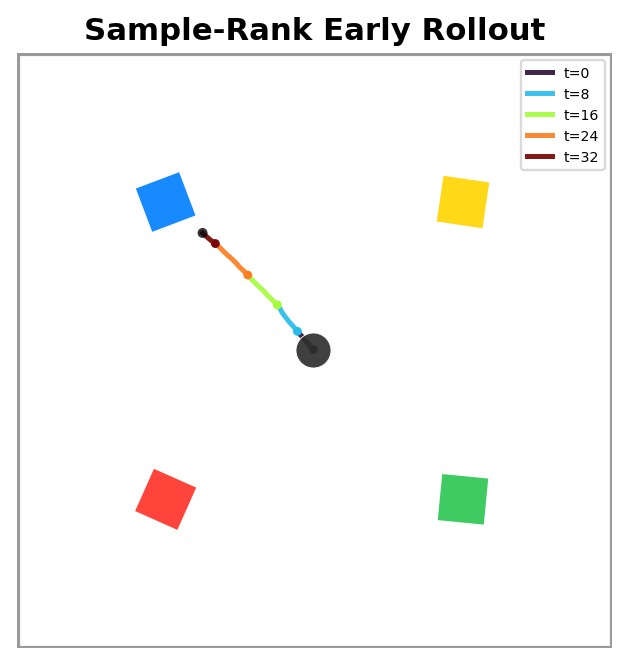

Saved sanity plot to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/sample_rank_prediction_sanity/20260429_152557/sample_rank_early_rollout.png


In [494]:
# Sanity check: sample-and-rank early rollout automaton predictions


import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils

try:
    from toy_squares.toy_squares_utils import _draw_blocks as _draw_toy_square_blocks
    from toy_squares.toy_squares_utils import _flip_y as _flip_toy_square_y
except ModuleNotFoundError:
    from toy_squares_utils import _draw_blocks as _draw_toy_square_blocks
    from toy_squares_utils import _flip_y as _flip_toy_square_y

def _format_onehot(values):
    return "[" + " ".join(f"{int(v):1d}" for v in values) + "]"


def _format_probs(values):
    return "[" + " ".join(f"{float(v):6.3f}" for v in values) + "]"


def _repeat_obs_batch(obs_tensor, n):
    if n == 1:
        return obs_tensor
    return {key: value.repeat((n,) + (1,) * (value.ndim - 1)) for key, value in obs_tensor.items()}


def _predict_future_label_probs(obs_tensor, action_chunk):
    state = _automaton_state_from_obs(obs_tensor).to(device=device, dtype=torch.float32)
    label = _automaton_label_from_state(state).to(device=device, dtype=torch.float32)
    action_flat = action_chunk.reshape(action_chunk.shape[0], -1).to(device=device, dtype=torch.float32)

    state_mean = torch.tensor(eval_stats["states_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    state_std = torch.tensor(eval_stats["states_std"], device=device, dtype=torch.float32).unsqueeze(0)
    action_mean = torch.tensor(eval_stats["actions_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    action_std = torch.tensor(eval_stats["actions_std"], device=device, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        logits = automaton_model((state - state_mean) / state_std, (action_flat - action_mean) / action_std, label)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
    return probs


def _unnormalize_action_sequence(action_sequence):
    action_np = _to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np

    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {
        key: policy.action_normalization_stats[key]["offset"].shape[1:]
        for key in policy.action_normalization_stats
    }
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)


def _plot_chunk_colored_plain_rollout(ax, low_level_obs, setup_state, records):
    palette = ["#0a84ff", "#ff3b30", "#34c759", "#ffd60a"]
    blocks = setup_state[2:10].reshape(4, 2) / 256.0 - 1.0
    angles = np.asarray(setup_state[10:14], dtype=float) if setup_state.shape[0] >= 14 else np.zeros(4)
    blocks = _flip_toy_square_y(blocks)
    angles = -angles
    trajectory = np.stack([_latest_low_level_vector(obs["agent_pos"]) for obs in low_level_obs], axis=0)
    trajectory = _flip_toy_square_y(trajectory)

    cmap = plt.get_cmap("turbo")
    for chunk_idx, record in enumerate(records):
        start = int(record["t"])
        end = int(records[chunk_idx + 1]["t"]) if chunk_idx + 1 < len(records) else len(trajectory) - 1
        if end <= start:
            continue
        points = trajectory[start:end + 1]
        color = cmap(chunk_idx / max(1, len(records) - 1))
        ax.plot(points[:, 0], points[:, 1], color=color, linewidth=2.1, alpha=0.92, label=f"t={start}", zorder=2)
        ax.scatter(points[0, 0], points[0, 1], s=14, color=color, edgecolors="none", zorder=4)

    _draw_toy_square_blocks(ax, blocks, angles, palette, radius=0.11, alpha=0.95, zorder=4)
    start_agent = trajectory[0]
    ax.scatter([start_agent[0]], [start_agent[1]], s=220, marker="o", c="#2f2f2f", alpha=0.92, edgecolors="white", linewidths=0.4, zorder=5)
    ax.scatter([trajectory[-1, 0]], [trajectory[-1, 1]], s=18, marker="o", c="#000000", alpha=0.78, edgecolors="none", zorder=6)
    ax.set_title("Sample-Rank Early Rollout", fontsize=13, fontweight="bold")
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")
    frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="#9a9a9a", linewidth=2.2, zorder=10)
    ax.add_patch(frame)
    if len(records) <= 12:
        ax.legend(loc="upper right", fontsize=6, frameon=True, framealpha=0.72, handlelength=1.8)


def run_sample_rank_early_prediction_sanity_check(horizon=200, target_label_idx=1, n_candidates=8):
    n_candidates = int(n_candidates)
    if n_candidates < 1:
        raise ValueError(f"n_candidates must be >= 1, got {n_candidates}.")
    setup_state = _to_numpy(early_decision_cube_setup(deterministic=True)).copy()
    obs = env.reset_to(setup_state)
    policy.start_episode()

    records = []
    action_queue = []
    total_reward = 0.0
    success = False
    steps = 0
    low_level_obs = [_obs_low_level_snapshot(obs)]

    for t in range(horizon):
        if not action_queue:
            current_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))
            obs_tensor = policy._prepare_observation(obs)
            obs_tensor_rank = _repeat_obs_batch(obs_tensor, n_candidates)
            with torch.no_grad():
                action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
            action_chunk = _unnormalize_action_sequence(action_chunk_n)
            action_chunk_tensor = torch.as_tensor(action_chunk, device=device, dtype=torch.float32)
            candidate_probs = _predict_future_label_probs(obs_tensor_rank, action_chunk_tensor)
            candidate_scores = candidate_probs[:, int(target_label_idx)]
            selected_idx = int(np.argmax(candidate_scores))
            pred_probs = candidate_probs[selected_idx].tolist()
            records.append({
                "t": t,
                "current_label": current_label["onehot"],
                "pred_probs": pred_probs,
                "selected_idx": selected_idx,
                "selected_score": float(candidate_scores[selected_idx]),
                "candidate_scores": candidate_scores.tolist(),
            })
            action_queue.extend(action_chunk[selected_idx])

        action = np.asarray(action_queue.pop(0), dtype=np.float32)
        obs, reward, done, info = env.step(action)
        low_level_obs.append(_obs_low_level_snapshot(obs))
        total_reward += float(reward)
        steps = t + 1
        success = success or bool(info.get("success", False) or float(reward) > 0)
        if done or success:
            break

    final_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]

    print(
        f"Sample-rank early rollout finished: target={target_label_idx} ({LABEL_NAMES[int(target_label_idx)]}), "
        f"N={n_candidates}, success={success}, steps={steps:03d}, return={total_reward:6.3f}"
    )
    print(f"{'t':>4}  {'pick':>4}  {'score':>7}  {'current':>9}  {'pred_future_prob':>31}  {'final':>9}")
    for record in records:
        print(
            f"{record['t']:4d}  "
            f"{record['selected_idx']:4d}  "
            f"{record['selected_score']:7.3f}  "
            f"{_format_onehot(record['current_label']):>9}  "
            f"{_format_probs(record['pred_probs']):>31}  "
            f"{_format_onehot(final_label):>9}"
        )

    sanity_dir = OUTPUT_ROOT / "sample_rank_prediction_sanity" / datetime.now().strftime("%Y%m%d_%H%M%S")
    sanity_dir.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        sanity_dir / "low_level_obs.npz",
        states=_stack_or_object([obs.get("states") for obs in low_level_obs]),
        agent_pos=_stack_or_object([obs.get("agent_pos") for obs in low_level_obs]),
    )
    np.save(sanity_dir / "setup_state.npy", setup_state)

    fig, ax = plt.subplots(1, 1, figsize=(3.8, 3.8), dpi=170, constrained_layout=True)
    _plot_chunk_colored_plain_rollout(ax, low_level_obs, setup_state, records)
    plot_path = sanity_dir / "sample_rank_early_rollout.png"
    fig.savefig(plot_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved sanity plot to {plot_path}")

    return records, final_label, plot_path

TARGET_RANK_LABEL_IDX = 1
SAMPLE_AND_RANK_N = 16
print("Label order: ['at_green', 'at_blue', 'at_red', 'at_yellow']")
print(f"Sample-and-rank target: {TARGET_RANK_LABEL_IDX} ({LABEL_NAMES[TARGET_RANK_LABEL_IDX]}), N={SAMPLE_AND_RANK_N}")

plain_prediction_records, plain_prediction_final_label, plain_prediction_plot_path = run_sample_rank_early_prediction_sanity_check(
    target_label_idx=TARGET_RANK_LABEL_IDX,
    n_candidates=SAMPLE_AND_RANK_N,
)

Summary:

1. Early Guidance: 
- Works perfectly for ALL blocks

2. Late Guidance:
- Perfect for outer blocks (blue, yellow)
- harder to guide to inner blocks (red, yellow maybe 10 - 30%), because the outer blocks are in the way ... 

Label order: ['at_green', 'at_blue', 'at_red', 'at_yellow']
Chain target: [1, 2, 0, 1, 3, 0] (['at_blue', 'at_red', 'at_green', 'at_blue', 'at_yellow', 'at_green']), N=8
Chain rollout finished: complete=True, stages=6/6, steps=389, return=53.000
Reached: ['at_blue', 'at_red', 'at_green', 'at_blue', 'at_yellow', 'at_green']
   t  stage     target  pick    score    current                 pred_future_prob      final
   0      0    at_blue     3    0.993  [0 0 0 0]    [ 0.000  0.993  0.001  0.000]  [1 0 0 0]
   8      0    at_blue     6    0.999  [0 0 0 0]    [ 0.000  0.999  0.000  0.000]  [1 0 0 0]
  16      0    at_blue     0    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [1 0 0 0]
  24      0    at_blue     0    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [1 0 0 0]
  32      0    at_blue     3    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [1 0 0 0]
  39      1     at_red     2    0.001  [0 1 0 0]    [ 0.000  0.478  0.001  0.000]  [1 0 0 0]
  47      1     at_red  

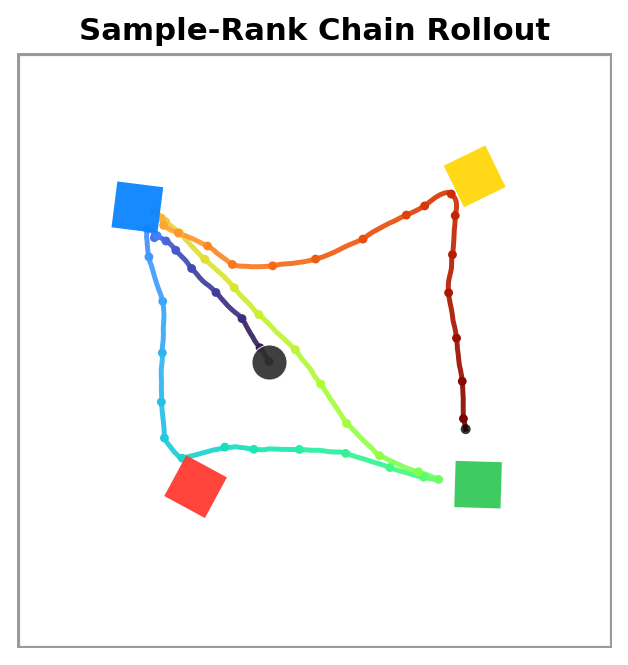

Image(value=b'GIF89a\x80\x00\x80\x00\x84\x00\x00\xff\xff\xff\xff\xff\x80\xff\xff@\xff\xff\x00\x80\xff\x80\x00\…

Saved chain plot to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/sample_rank_chain_sanity/chain_1-2-0-1-3-0_n8_20260429_154034/sample_rank_chain_rollout.png
Saved chain GIF to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/sample_rank_chain_sanity/chain_1-2-0-1-3-0_n8_20260429_154034/sample_rank_chain_rollout.gif


In [495]:
# Sanity check: sample-and-rank toward an ordered chain of labels


import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils

try:
    from toy_squares.toy_squares_utils import _draw_blocks as _draw_toy_square_blocks
    from toy_squares.toy_squares_utils import _flip_y as _flip_toy_square_y
except ModuleNotFoundError:
    from toy_squares_utils import _draw_blocks as _draw_toy_square_blocks
    from toy_squares_utils import _flip_y as _flip_toy_square_y


def _chain_repeat_obs_batch(obs_tensor, n):
    if n == 1:
        return obs_tensor
    return {key: value.repeat((n,) + (1,) * (value.ndim - 1)) for key, value in obs_tensor.items()}


def _chain_predict_future_label_probs(obs_tensor, action_chunk):
    state = _automaton_state_from_obs(obs_tensor).to(device=device, dtype=torch.float32)
    label = _automaton_label_from_state(state).to(device=device, dtype=torch.float32)
    action_flat = action_chunk.reshape(action_chunk.shape[0], -1).to(device=device, dtype=torch.float32)

    state_mean = torch.tensor(eval_stats["states_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    state_std = torch.tensor(eval_stats["states_std"], device=device, dtype=torch.float32).unsqueeze(0)
    action_mean = torch.tensor(eval_stats["actions_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    action_std = torch.tensor(eval_stats["actions_std"], device=device, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        logits = automaton_model((state - state_mean) / state_std, (action_flat - action_mean) / action_std, label)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
    return probs


def _chain_unnormalize_action_sequence(action_sequence):
    action_np = _to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np

    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {
        key: policy.action_normalization_stats[key]["offset"].shape[1:]
        for key in policy.action_normalization_stats
    }
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)


def _chain_format_onehot(values):
    return "[" + " ".join(f"{int(v):1d}" for v in values) + "]"


def _chain_format_probs(values):
    return "[" + " ".join(f"{float(v):6.3f}" for v in values) + "]"


def _plot_chunk_colored_chain_rollout(ax, low_level_obs, setup_state, records):
    palette = ["#0a84ff", "#ff3b30", "#34c759", "#ffd60a"]
    blocks = setup_state[2:10].reshape(4, 2) / 256.0 - 1.0
    angles = np.asarray(setup_state[10:14], dtype=float) if setup_state.shape[0] >= 14 else np.zeros(4)
    blocks = _flip_toy_square_y(blocks)
    angles = -angles
    trajectory = np.stack([_latest_low_level_vector(obs["agent_pos"]) for obs in low_level_obs], axis=0)
    trajectory = _flip_toy_square_y(trajectory)

    cmap = plt.get_cmap("turbo")
    for chunk_idx, record in enumerate(records):
        start = int(record["t"])
        end = int(records[chunk_idx + 1]["t"]) if chunk_idx + 1 < len(records) else len(trajectory) - 1
        if end <= start:
            continue
        points = trajectory[start:end + 1]
        color = cmap(chunk_idx / max(1, len(records) - 1))
        target_name = LABEL_NAMES[int(record["target_label_idx"])]
        ax.plot(points[:, 0], points[:, 1], color=color, linewidth=2.1, alpha=0.92, label=f"t={start} {target_name}", zorder=2)
        ax.scatter(points[0, 0], points[0, 1], s=14, color=color, edgecolors="none", zorder=4)

    _draw_toy_square_blocks(ax, blocks, angles, palette, radius=0.11, alpha=0.95, zorder=4)
    start_agent = trajectory[0]
    ax.scatter([start_agent[0]], [start_agent[1]], s=220, marker="o", c="#2f2f2f", alpha=0.92, edgecolors="white", linewidths=0.4, zorder=5)
    ax.scatter([trajectory[-1, 0]], [trajectory[-1, 1]], s=18, marker="o", c="#000000", alpha=0.78, edgecolors="none", zorder=6)
    ax.set_title("Sample-Rank Chain Rollout", fontsize=13, fontweight="bold")
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")
    frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="#9a9a9a", linewidth=2.2, zorder=10)
    ax.add_patch(frame)
    if len(records) <= 12:
        ax.legend(loc="upper right", fontsize=5.5, frameon=True, framealpha=0.72, handlelength=1.8)


def run_sample_rank_chain_sanity_check(label_chain, n_candidates=8, horizon=200, deterministic_setup=True):
    label_chain = [int(idx) for idx in label_chain]
    n_candidates = int(n_candidates)
    if not label_chain:
        raise ValueError("label_chain must contain at least one label index.")
    if n_candidates < 1:
        raise ValueError(f"n_candidates must be >= 1, got {n_candidates}.")

    setup_state = _to_numpy(early_decision_cube_setup(deterministic=deterministic_setup)).copy()
    obs = env.reset_to(setup_state)
    policy.start_episode()

    records = []
    reaches = []
    action_queue = []
    total_reward = 0.0
    steps = 0
    chain_pos = 0
    low_level_obs = [_obs_low_level_snapshot(obs)]
    frames = [_render_frame(env)]

    for t in range(horizon):
        if not action_queue:
            target_label_idx = label_chain[chain_pos]
            current_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))
            obs_tensor = policy._prepare_observation(obs)
            obs_tensor_rank = _chain_repeat_obs_batch(obs_tensor, n_candidates)
            with torch.no_grad():
                action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
            action_chunk = _chain_unnormalize_action_sequence(action_chunk_n)
            action_chunk_tensor = torch.as_tensor(action_chunk, device=device, dtype=torch.float32)
            candidate_probs = _chain_predict_future_label_probs(obs_tensor_rank, action_chunk_tensor)
            candidate_scores = candidate_probs[:, target_label_idx]
            selected_idx = int(np.argmax(candidate_scores))
            pred_probs = candidate_probs[selected_idx].tolist()
            records.append({
                "t": t,
                "stage": chain_pos,
                "target_label_idx": target_label_idx,
                "current_label": current_label["onehot"],
                "pred_probs": pred_probs,
                "selected_idx": selected_idx,
                "selected_score": float(candidate_scores[selected_idx]),
                "candidate_scores": candidate_scores.tolist(),
            })
            action_queue.extend(action_chunk[selected_idx])

        action = np.asarray(action_queue.pop(0), dtype=np.float32)
        obs, reward, done, info = env.step(action)
        low_level_obs.append(_obs_low_level_snapshot(obs))
        frames.append(_render_frame(env))
        total_reward += float(reward)
        steps = t + 1

        current_onehot = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]
        if chain_pos < len(label_chain) and int(current_onehot[label_chain[chain_pos]]) == 1:
            reaches.append({"t": steps, "stage": chain_pos, "label_idx": label_chain[chain_pos], "label_name": LABEL_NAMES[label_chain[chain_pos]]})
            chain_pos += 1
            action_queue.clear()
            if chain_pos >= len(label_chain):
                break

    final_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]
    complete = chain_pos >= len(label_chain)
    chain_names = [LABEL_NAMES[idx] for idx in label_chain]
    reached_names = [item["label_name"] for item in reaches]

    print(f"Chain target: {label_chain} ({chain_names}), N={n_candidates}")
    print(f"Chain rollout finished: complete={complete}, stages={chain_pos}/{len(label_chain)}, steps={steps:03d}, return={total_reward:6.3f}")
    print(f"Reached: {reached_names}")
    print(f"{'t':>4}  {'stage':>5}  {'target':>9}  {'pick':>4}  {'score':>7}  {'current':>9}  {'pred_future_prob':>31}  {'final':>9}")
    for record in records:
        target_name = LABEL_NAMES[int(record["target_label_idx"])]
        print(
            f"{record['t']:4d}  "
            f"{record['stage']:5d}  "
            f"{target_name:>9}  "
            f"{record['selected_idx']:4d}  "
            f"{record['selected_score']:7.3f}  "
            f"{_chain_format_onehot(record['current_label']):>9}  "
            f"{_chain_format_probs(record['pred_probs']):>31}  "
            f"{_chain_format_onehot(final_label):>9}"
        )

    chain_tag = "-".join(str(idx) for idx in label_chain)
    sanity_dir = OUTPUT_ROOT / "sample_rank_chain_sanity" / f"chain_{chain_tag}_n{n_candidates}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    sanity_dir.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        sanity_dir / "low_level_obs.npz",
        states=_stack_or_object([obs.get("states") for obs in low_level_obs]),
        agent_pos=_stack_or_object([obs.get("agent_pos") for obs in low_level_obs]),
    )
    np.save(sanity_dir / "setup_state.npy", setup_state)
    with open(sanity_dir / "chain_summary.json", "w", encoding="utf-8") as f:
        json.dump({
            "label_chain": label_chain,
            "chain_names": chain_names,
            "n_candidates": n_candidates,
            "complete": complete,
            "steps": steps,
            "return": total_reward,
            "reaches": reaches,
            "records": records,
        }, f, indent=2)

    fig, ax = plt.subplots(1, 1, figsize=(3.8, 3.8), dpi=170, constrained_layout=True)
    _plot_chunk_colored_chain_rollout(ax, low_level_obs, setup_state, records)
    plot_path = sanity_dir / "sample_rank_chain_rollout.png"
    fig.savefig(plot_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    gif_path = sanity_dir / "sample_rank_chain_rollout.gif"
    imageio.mimsave(gif_path, frames, duration=0.12)
    display(widgets.Image(value=gif_path.read_bytes(), format="gif", layout=widgets.Layout(width="260px")))
    print(f"Saved chain plot to {plot_path}")
    print(f"Saved chain GIF to {gif_path}")

    return records, reaches, complete, plot_path, gif_path

CHAIN_LABEL_IDXS = [1, 2, 0, 1, 3, 0]  # at_blue -> at_red -> at_green -> at_blue -> at_yellow -> at_green
CHAIN_SAMPLE_AND_RANK_N = 8
CHAIN_HORIZON = 400
CHAIN_DETERMINISTIC_SETUP = False 

print("Label order: ['at_green', 'at_blue', 'at_red', 'at_yellow']")
chain_records, chain_reaches, chain_complete, chain_plot_path, chain_gif_path = run_sample_rank_chain_sanity_check(
    label_chain=CHAIN_LABEL_IDXS,
    n_candidates=CHAIN_SAMPLE_AND_RANK_N,
    horizon=CHAIN_HORIZON,
    deterministic_setup=CHAIN_DETERMINISTIC_SETUP,
)